In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/miadul/house-price-prediction-dataset/house_price_50k.csv


#  House Price Analysis (EDA)

##  Problem Statement
The objective of this project is to analyze housing data and understand the factors that influence house prices.

##  Objective
- To explore the dataset using data visualization
- To identify important features affecting house price
- To find patterns and relationships between variables

##  Dataset Description
The dataset includes information such as:
- Area
- Bedrooms and bathrooms
- Location
- Income level
- Price of the house

##  Tools Used
- Python
- Pandas
- Matplotlib & Seaborn

##  Approach
1. Data Understanding  
2. Data Cleaning  
3. Exploratory Data Analysis (EDA)  
4. Insights & Conclusion  

---

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/miadul/house-price-prediction-dataset/house_price_50k.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

##  Data Loading

**Objective:** Load the dataset and view its structure.

In [4]:
df = pd.read_csv('/kaggle/input/datasets/miadul/house-price-prediction-dataset/house_price_50k.csv')
df.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1.792425e+06


##  Data Understanding

**Objective:** Understand the structure, data types, and summary of the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

In [6]:
df.shape

(50000, 19)

In [7]:
df.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04
mean,2752.970540,3.496040,2.498040,1.997060,19.573740,14.968700,0.500540,0.497300,0.500280,0.496220,0.501100,0.498320,0.498320,0.500040,5.006444,5065.94598,1.030261e+06
std,1297.148134,1.712146,1.117704,0.815368,11.552502,8.363714,0.500005,0.499998,0.500005,0.499991,0.500004,0.500002,0.500002,0.500005,2.876776,2864.34322,4.580199e+05
min,500.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000311,100.00000,9.090069e+04
25%,1630.000000,2.000000,1.000000,1.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.523018,2575.00000,6.357375e+05
50%,2756.000000,3.000000,2.000000,2.000000,20.000000,15.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.022946,5060.50000,1.031763e+06
75%,3872.000000,5.000000,3.000000,3.000000,30.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.479632,7543.00000,1.423102e+06
max,4999.000000,6.000000,4.000000,3.000000,39.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999869,9999.00000,1.996474e+06


##  Missing Values Check

**Objective:** Identify missing values in the dataset.

In [8]:
df.isnull().sum()

area                    0
bedrooms                0
bathrooms               0
floors                  0
age                     0
distance                0
garage                  0
parking                 0
garden                  0
security                0
school_nearby           0
hospital_nearby         0
shopping_mall_nearby    0
public_transport        0
crime_rate              0
population_density      0
location                0
income_level            0
price                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

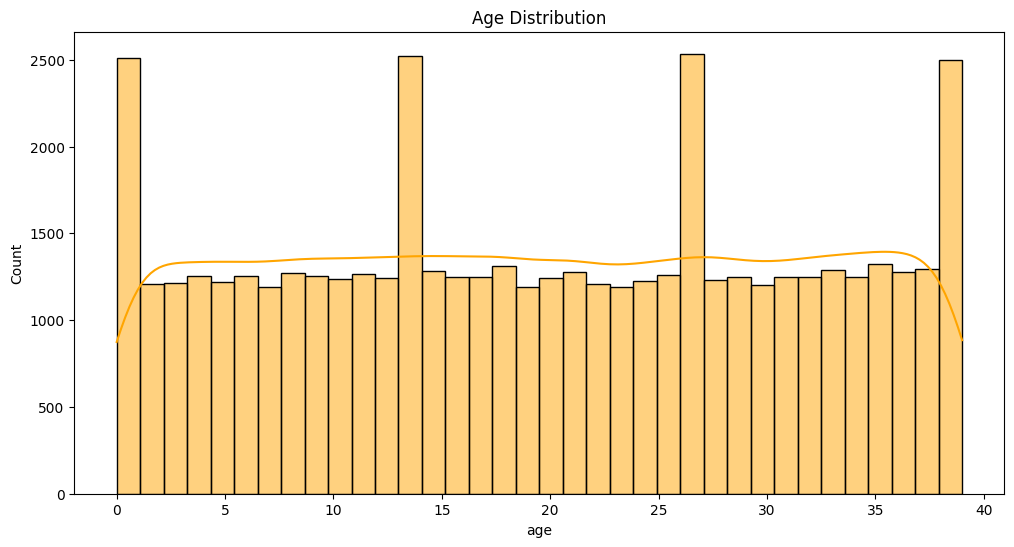

In [10]:
fig = plt.figure(figsize=(12,6))
sns.histplot(df['age'], kde=True, color='orange')
plt.title("Age Distribution")
plt.show()

### Age Distribution Analysis

The distribution of property age appears to be nearly uniform across the dataset, with no significant peaks or dominant age groups. This indicates that properties of different ages are evenly represented.

The absence of skewness suggests a balanced dataset, and no noticeable outliers are observed. Overall, age does not show any strong concentration in a specific range.

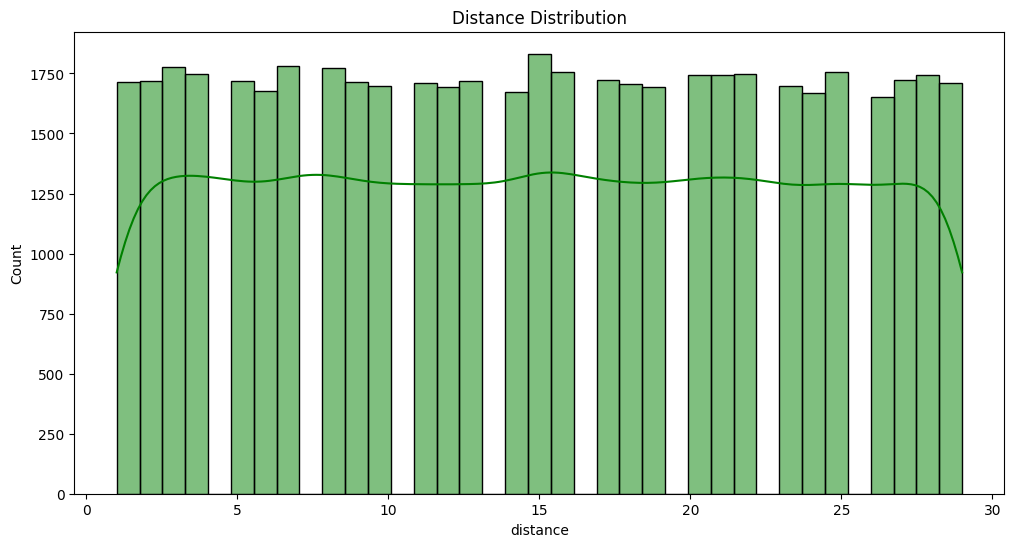

In [11]:
fig = plt.figure(figsize=(12,6))
sns.histplot(df['distance'], kde=True, color='green')
plt.title("Distance Distribution")
plt.show()

### Distance Distribution Analysis

The distribution of distance appears to be uniform across the dataset, with no significant peaks or dominant ranges. This indicates that properties are evenly distributed across different distance values.

The absence of skewness suggests a balanced dataset, and no noticeable outliers are observed.

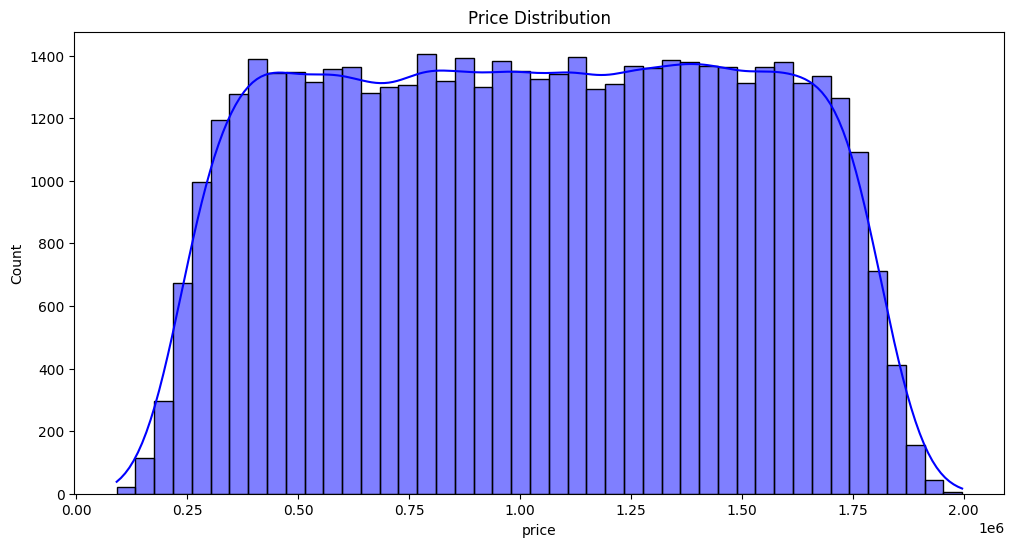

In [12]:
fig = plt.figure(figsize=(12,6))
sns.histplot(df['price'], kde=True, color='blue')
plt.title("Price Distribution")
plt.show()

### Price Distribution Analysis

The distribution of house prices is relatively uniform across a wide range, with no significant peak or dominant price segment. Most properties are spread evenly across different price levels.

A slight decline is observed at the extreme low and high ends, indicating fewer properties in those ranges. Overall, the distribution does not exhibit strong skewness.

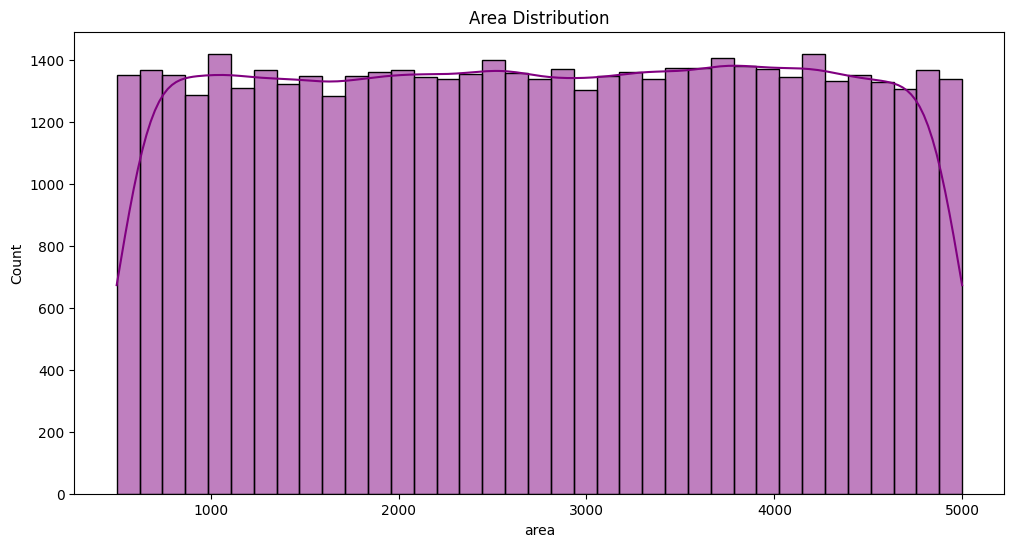

In [13]:
fig = plt.figure(figsize=(12,6))
sns.histplot(df['area'], kde=True, color='purple')
plt.title("Area Distribution")
plt.show()

### Area Distribution Analysis

The distribution of property area appears to be uniform across the dataset, with no specific range dominating the data. Properties of varying sizes, from small to large, are evenly represented.

The absence of skewness indicates a balanced dataset, and no significant outliers are observed.

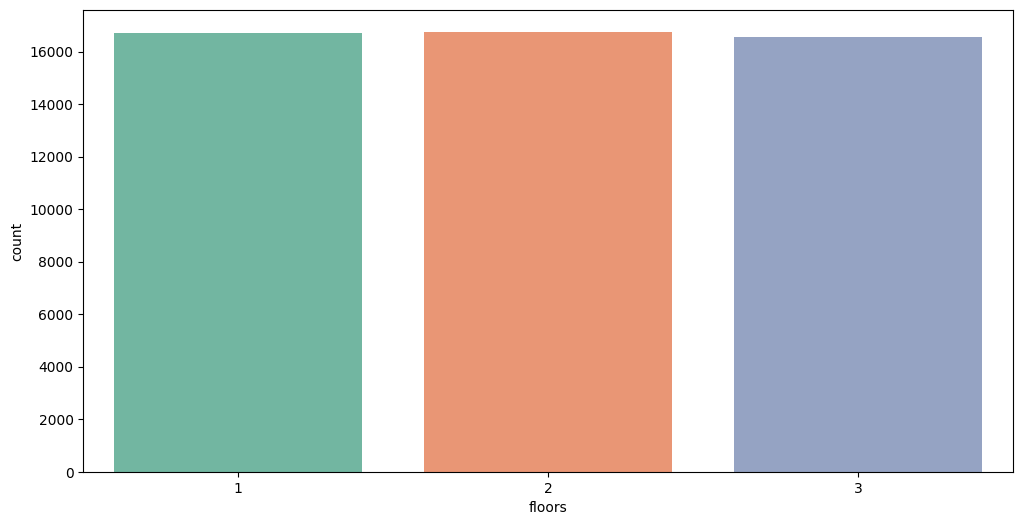

In [14]:
fig = plt.figure(figsize=(12,6))
sns.countplot(x='floors', data=df, palette = 'Set2')
plt.show()

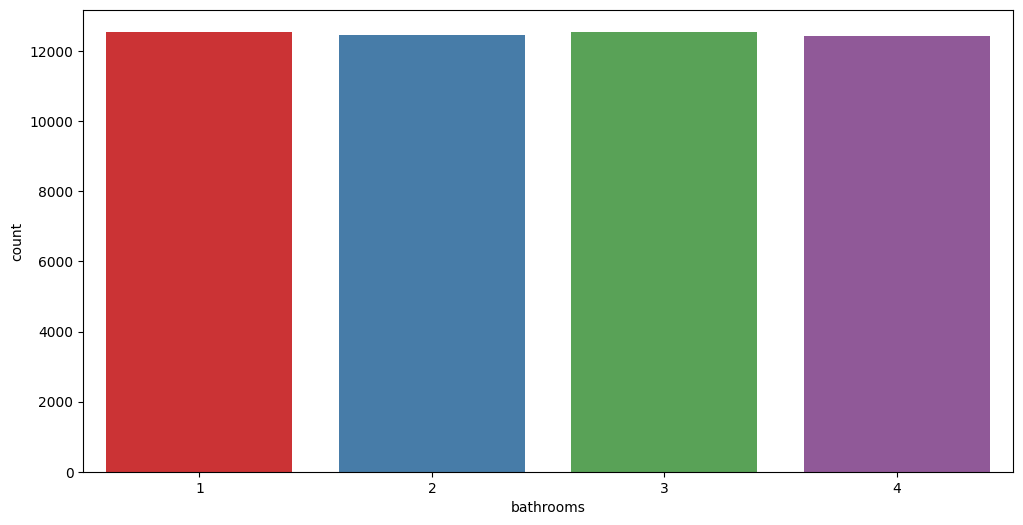

In [15]:
fig = plt.figure(figsize=(12,6))
sns.countplot(x='bathrooms', data=df, palette = 'Set1')
plt.show()

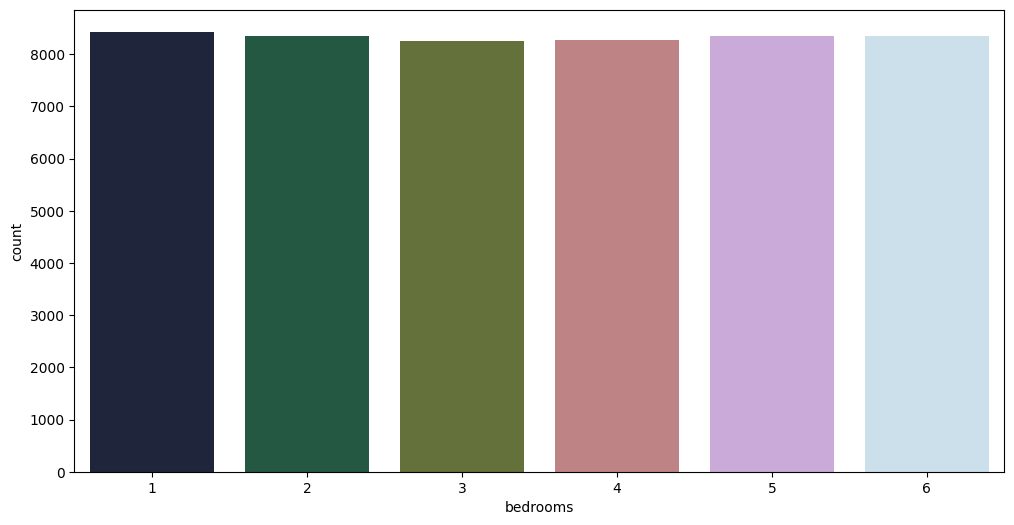

In [16]:
fig = plt.figure(figsize=(12,6))
sns.countplot(x='bedrooms', data=df, palette = 'cubehelix')
plt.show()

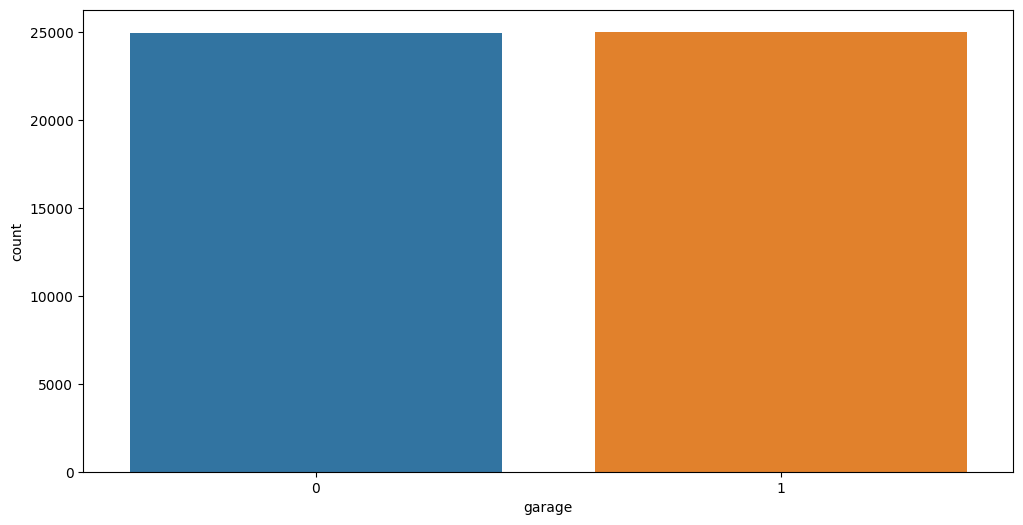

In [17]:
fig = plt.figure(figsize=(12,6))
sns.countplot(x='garage', data=df, palette = 'tab10')
plt.show()

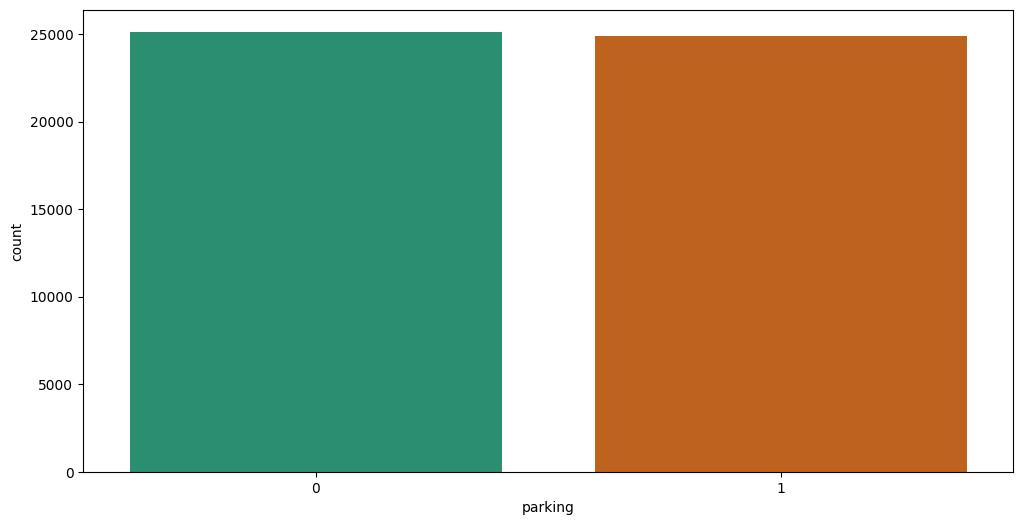

In [18]:
fig = plt.figure(figsize=(12,6))
sns.countplot(x='parking', data=df, palette = 'Dark2')
plt.show()

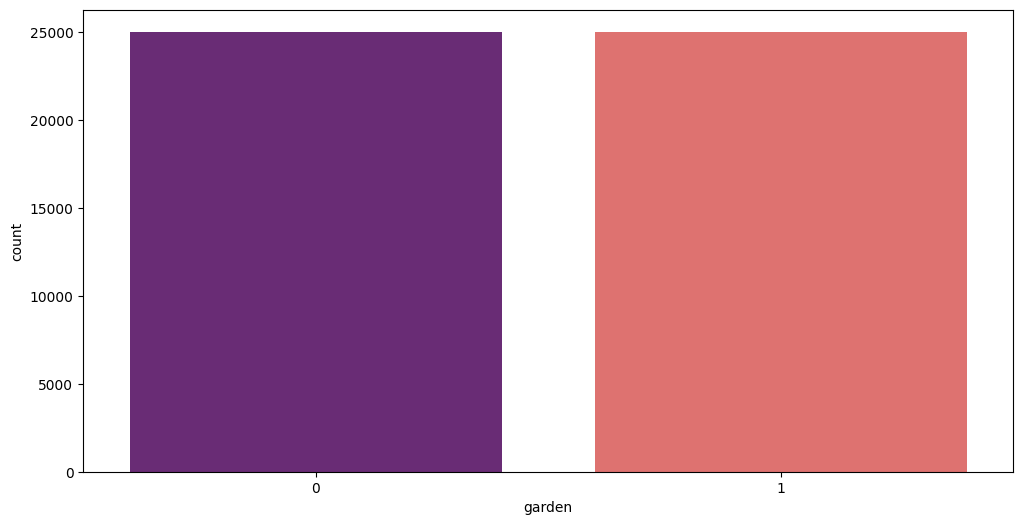

In [19]:
fig = plt.figure(figsize=(12,6))
sns.countplot(x='garden', data=df, palette = 'magma')
plt.show()

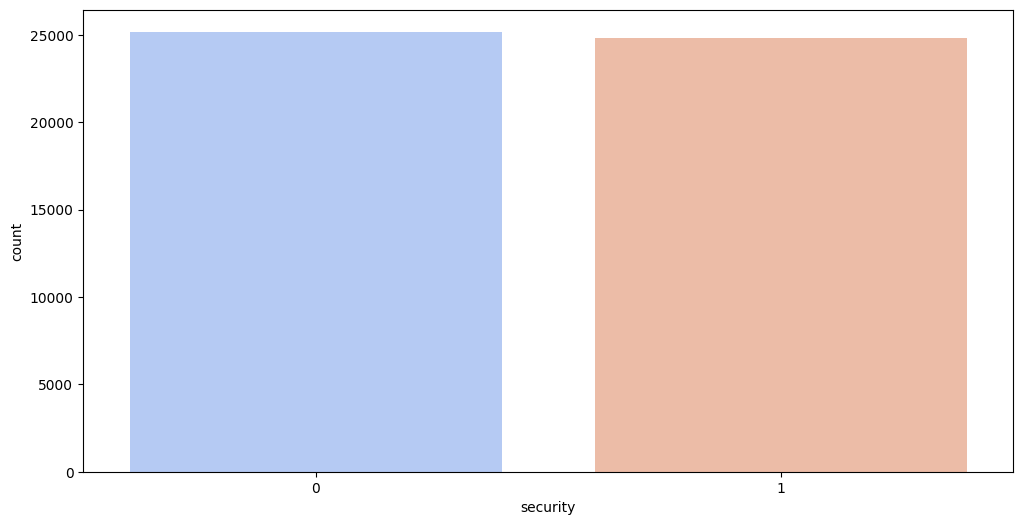

In [20]:
fig = plt.figure(figsize=(12,6))
sns.countplot(x='security', data=df, palette = 'coolwarm')
plt.show()

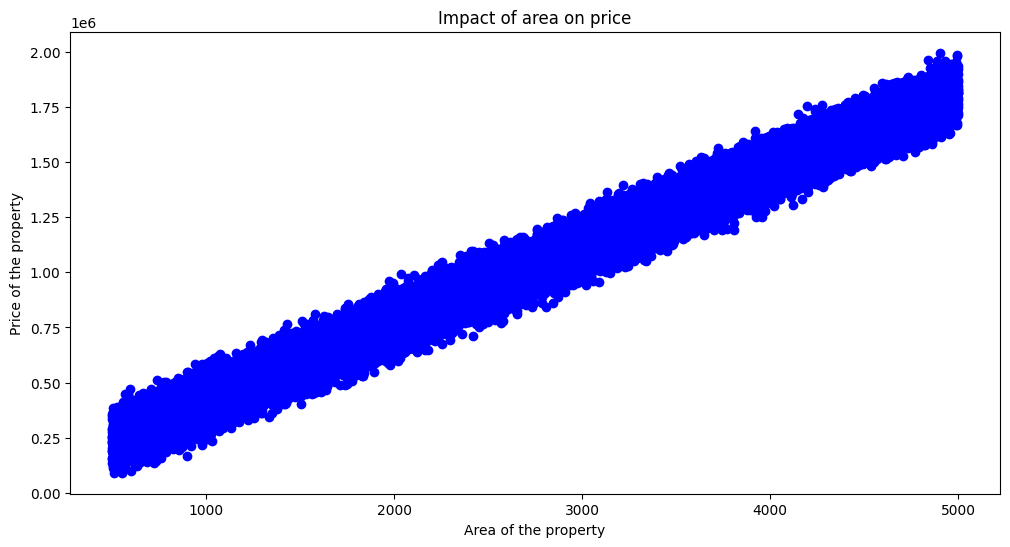

In [21]:
fig = plt.figure(figsize=(12,6))
plt.scatter(x='area',y='price',data=df, color="blue")
plt.title("Impact of area on price")
plt.xlabel("Area of the property")
plt.ylabel("Price of the property")
plt.show()

### Impact of Area on Price

The scatter plot shows a strong positive relationship between property area and price. As the area increases, the price of the property also increases consistently.

The linear pattern suggests that area is a key factor influencing house prices.

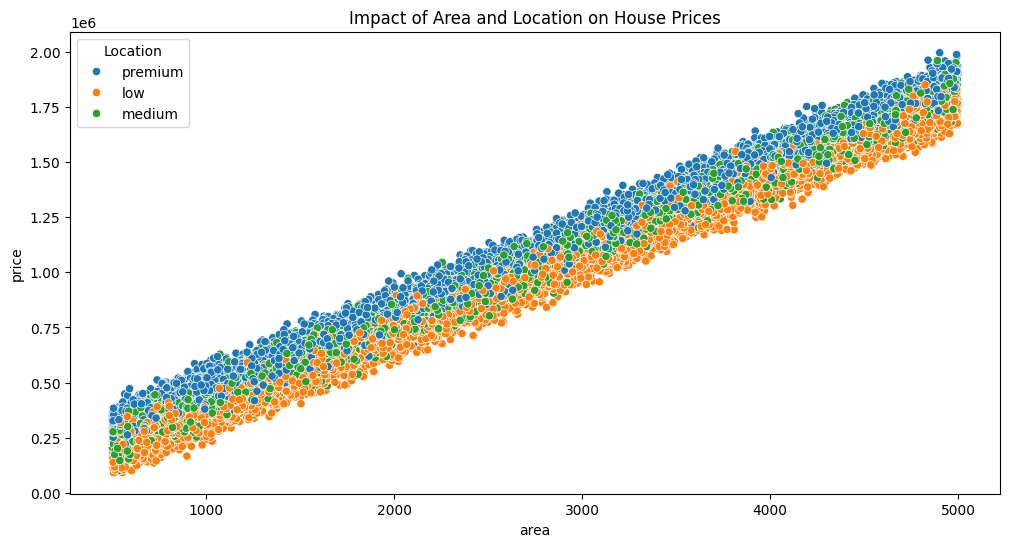

In [22]:
fig = plt.figure(figsize=(12,6))
sns.scatterplot(x='area', y='price', hue='location', data=df)
plt.title("Impact of Area and Location on House Prices")
plt.legend(title="Location")
plt.show()

### Impact of Area and Location on House Prices

The scatter plot shows a strong positive relationship between property area and price, indicating that larger properties tend to have higher prices.

Additionally, location plays a significant role in determining price levels. For the same area, properties in premium locations consistently have higher prices compared to medium and low locations.


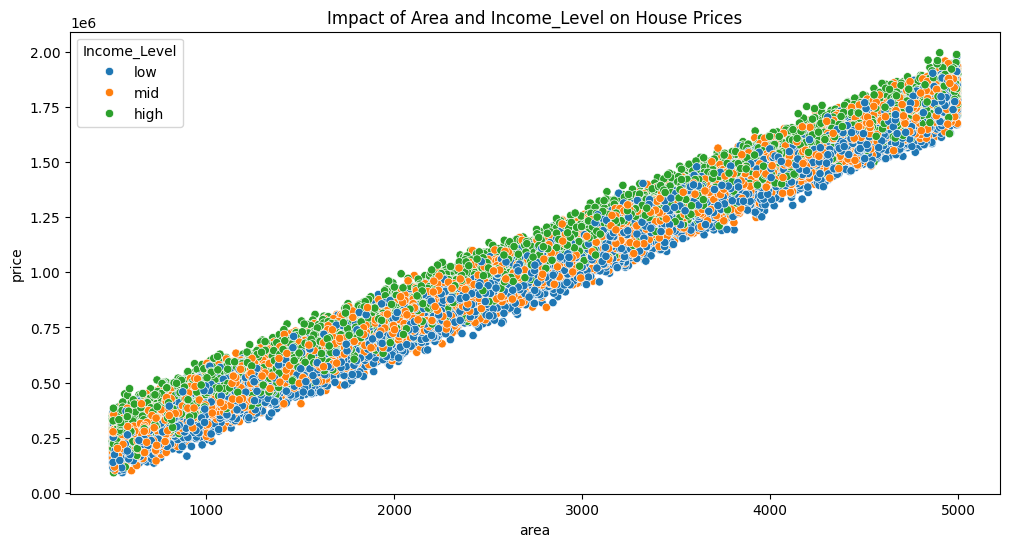

In [23]:
fig = plt.figure(figsize=(12,6))
sns.scatterplot(x='area', y='price', hue='income_level', data=df)
plt.title("Impact of Area and Income_Level on House Prices")
plt.legend(title="Income_Level")
plt.show()

### Impact of Area and Income Level on House Prices

The scatter plot shows a strong positive relationship between property area and price, indicating that larger properties tend to have higher prices.

Income level also influences house prices, as properties in high-income areas are generally priced higher than those in mid and low-income areas for the same property size.


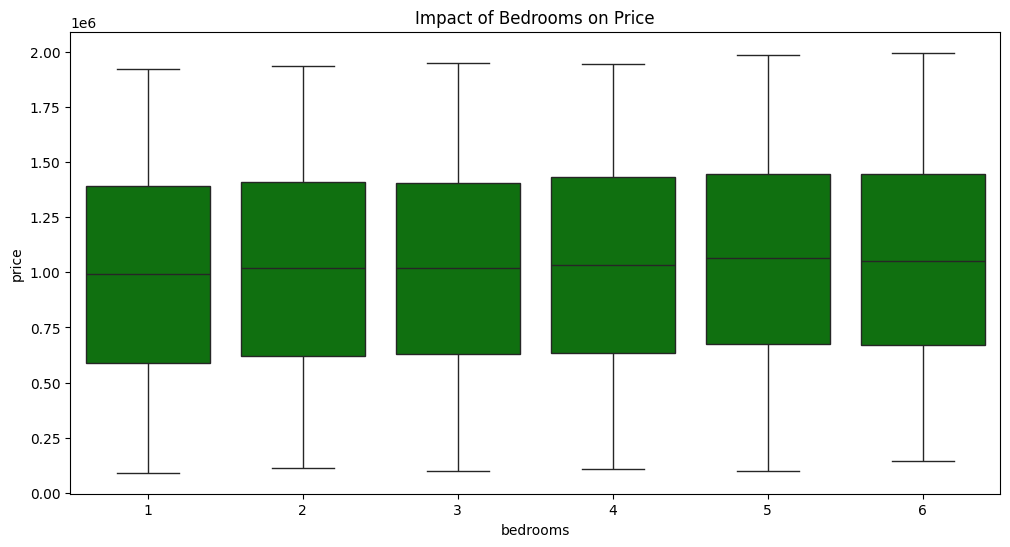

In [24]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x='bedrooms', y='price', data=df, color='green')
plt.title("Impact of Bedrooms on Price")
plt.show()

### Impact of Bedrooms on House Prices

The boxplot shows that house prices remain relatively consistent across different bedroom categories. The median price does not vary significantly as the number of bedrooms increases.

There is a high degree of overlap between categories, indicating that the number of bedrooms alone does not strongly influence house prices.

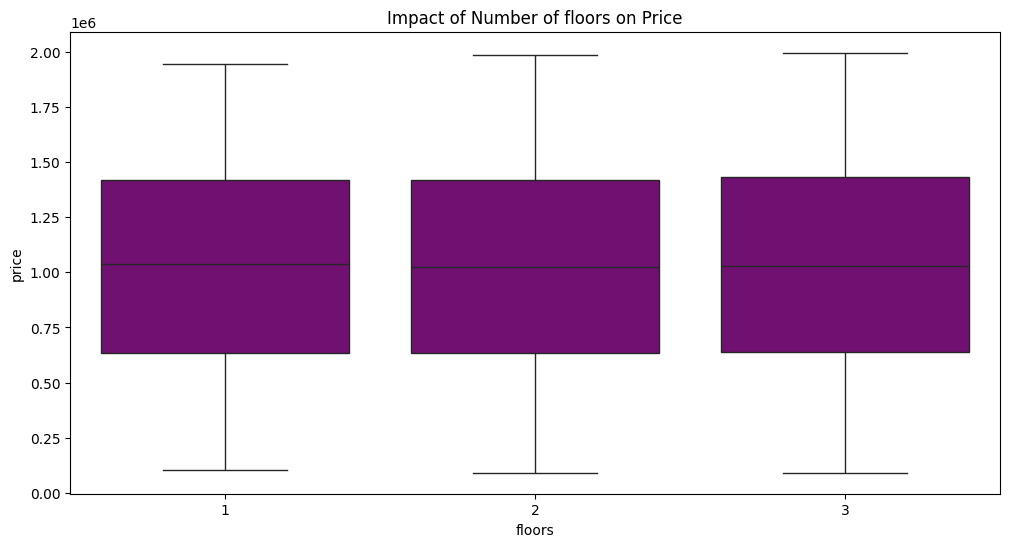

In [25]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x="floors", y="price", data=df, color='purple')
plt.title("Impact of Number of floors on Price")
plt.show()

### Impact of Number of Floors on Price

The boxplot shows that house prices remain relatively consistent across properties with different numbers of floors. The median price does not vary significantly between 1, 2, and 3-floor properties.

The high overlap between categories indicates that the number of floors has a weak influence on house prices.

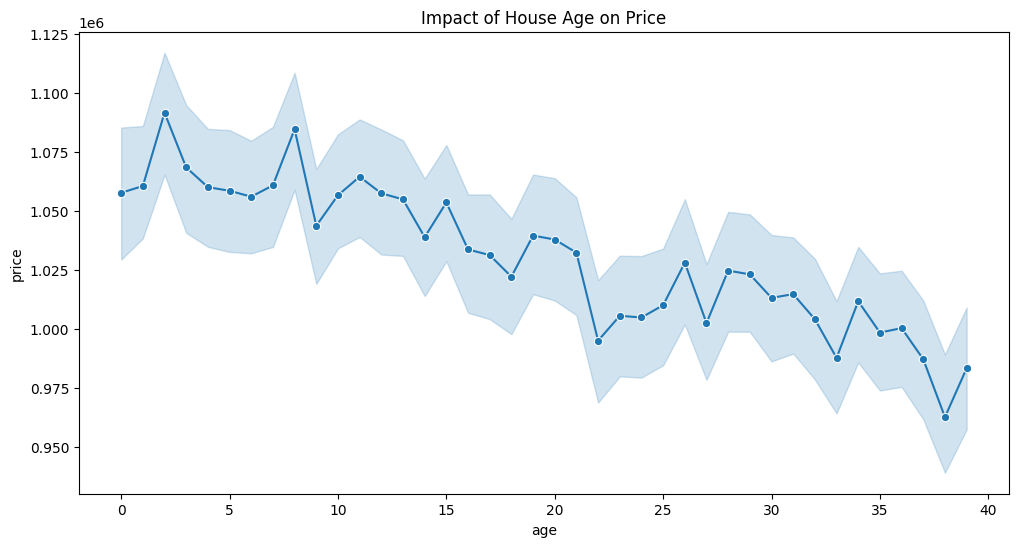

In [26]:
fig = plt.figure(figsize=(12,6))
sns.lineplot(x='age', y='price', data=df, estimator='mean', marker='o')
plt.title("Impact of House Age on Price")
plt.show()

### Impact of House Age on Price

The line plot shows a slight decreasing trend in house prices as the property age increases. However, the change in price is minimal across different age groups.



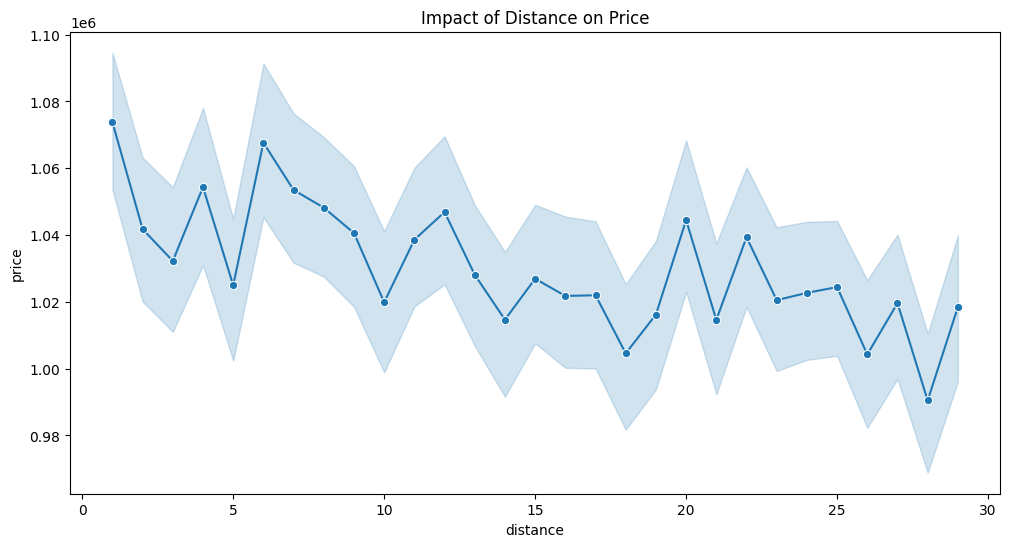

In [27]:
fig = plt.figure(figsize=(12,6))
sns.lineplot(x='distance', y='price', data=df, estimator='mean', marker='o')
plt.title("Impact of Distance on Price")
plt.show()

### Impact of Distance on Price

The analysis indicates a weak negative relationship between distance and house price, with prices showing a slight decline as distance increases.

However, the overall variation is minimal and the confidence intervals overlap significantly, suggesting that distance is not a strong predictor of house prices. More influential features such as area and location play a greater role.

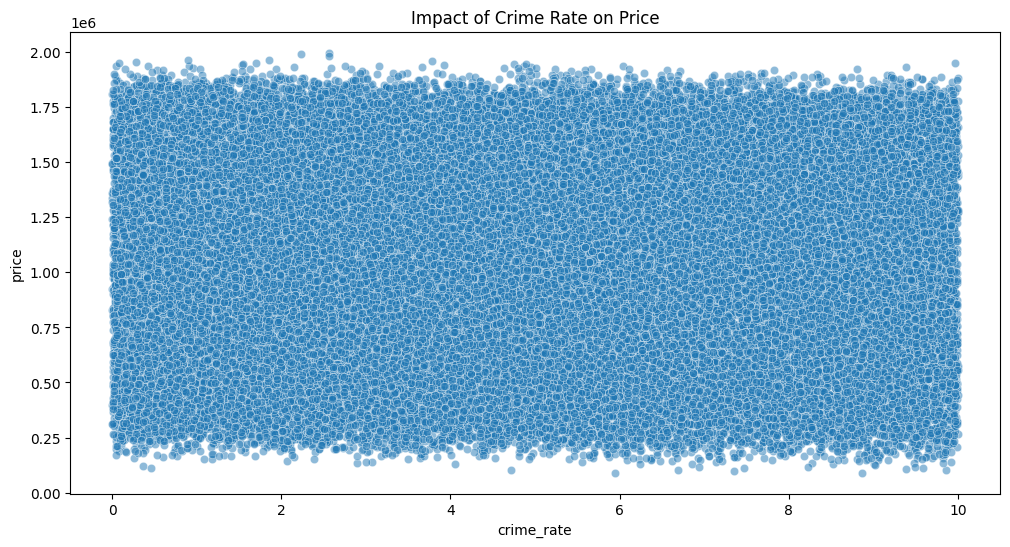

In [28]:
fig = plt.figure(figsize=(12,6))
sns.scatterplot(x='crime_rate', y='price', data=df, alpha=0.5)
plt.title("Impact of Crime Rate on Price")
plt.show()

### Impact of Crime Rate on Price

The analysis reveals no meaningful relationship between crime rate and house price. The price values are widely spread across all crime rate levels, and no clear trend is observed.

This suggests that crime rate is not a strong predictor of house prices and has minimal impact compared to more influential features such as area and location.

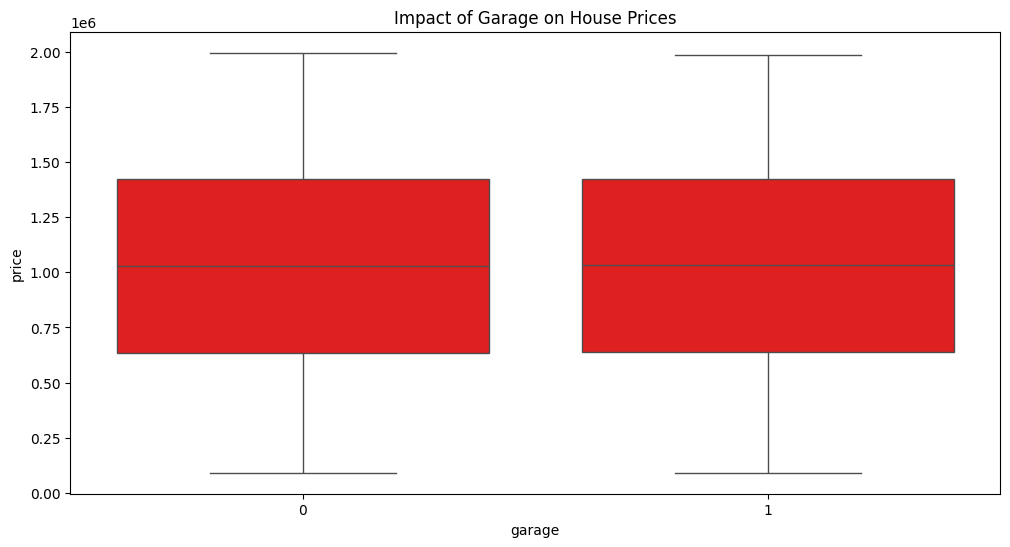

In [29]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x="garage", y="price", data=df, color='red')
plt.title("Impact of Garage on House Prices")
plt.show()

Compared to key features like area and location, the presence of a garage has a significantly weaker influence on house prices.

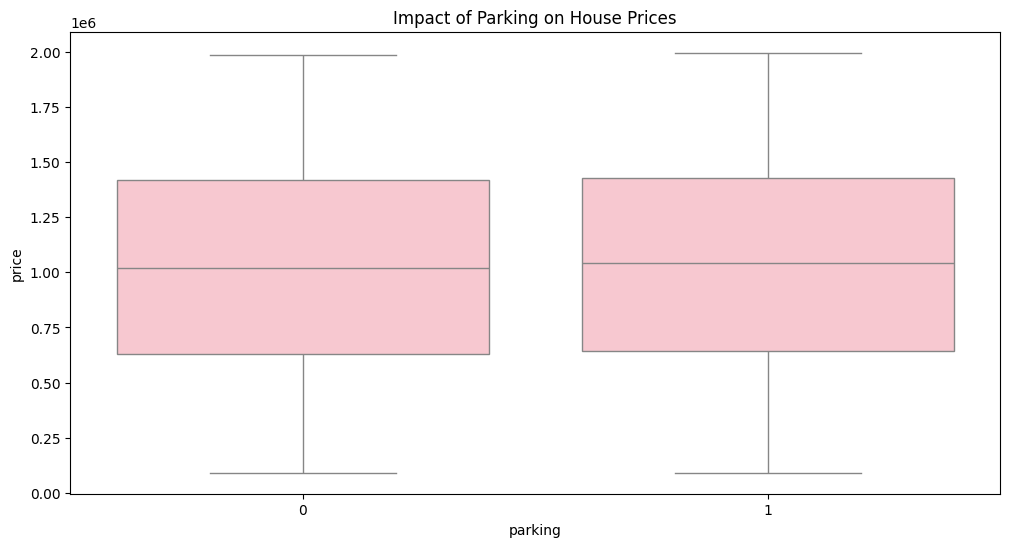

In [30]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x="parking",y="price", data=df, color='pink')
plt.title("Impact of Parking on House Prices")
plt.show()

Compared to key features like area and location, the presence of a Parking has a significantly weaker influence on house prices.

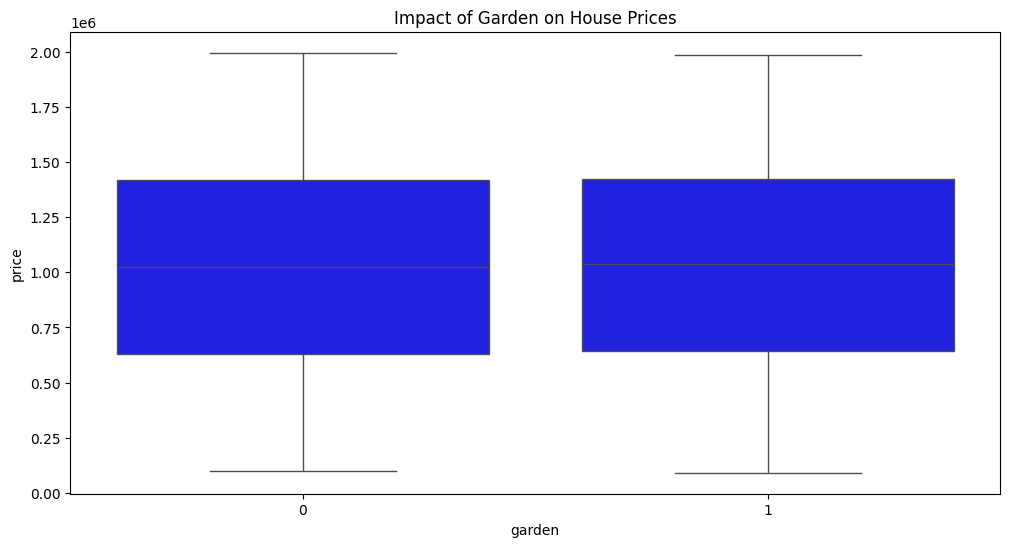

In [31]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x="garden", y="price", data=df, color='blue')
plt.title("Impact of Garden on House Prices")
plt.show()

Compared to key features like area and location, the presence of a garden has a significantly weaker influence on house prices.

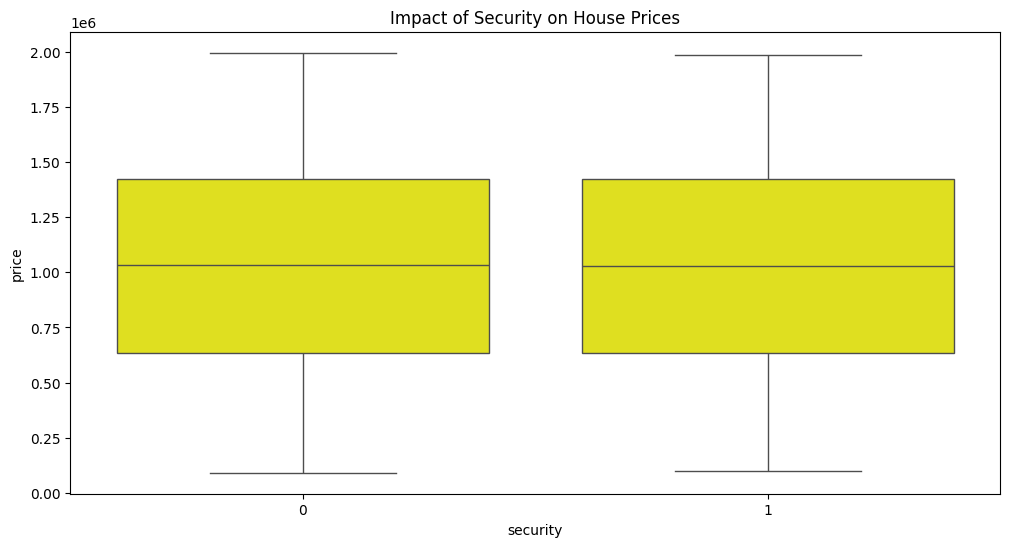

In [32]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x="security", y="price", data=df, color='yellow')
plt.title("Impact of Security on House Prices")
plt.show()

Compared to key features like area and location, the presence of a Security has a significantly weaker influence on house prices.

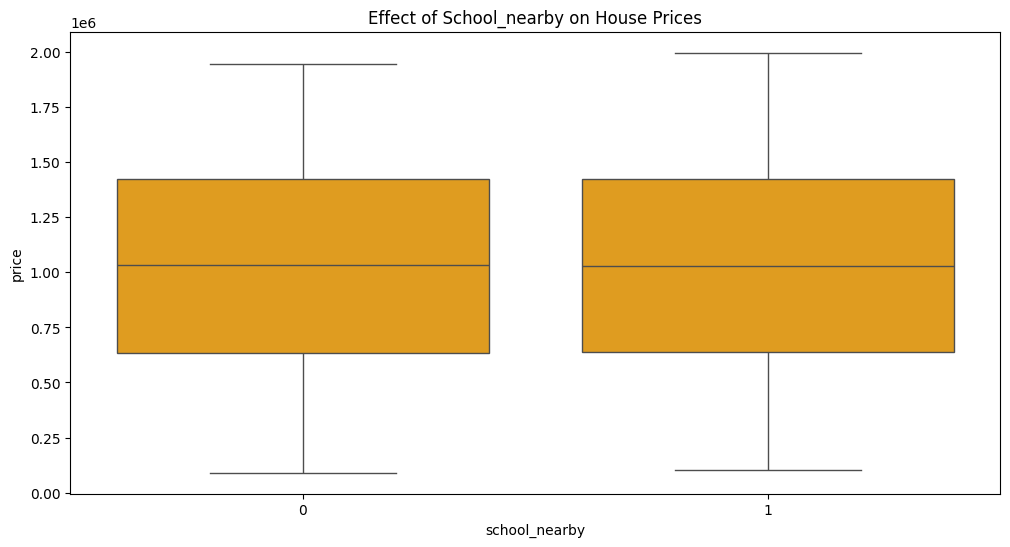

In [33]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x='school_nearby', y="price", data=df, color='orange')
plt.title("Effect of School_nearby on House Prices")
plt.show()

Compared to key features like area and location, school proximity has a significantly weaker influence on house prices.

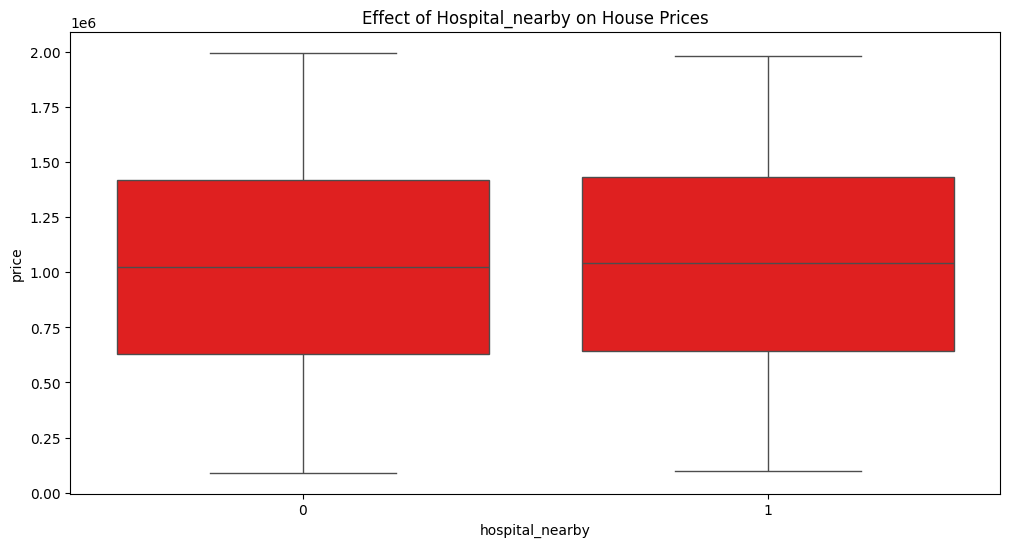

In [34]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x="hospital_nearby", y="price", data=df, color='red')
plt.title("Effect of Hospital_nearby on House Prices")
plt.show()

Compared to key features such as area and location, hospital proximity has a significantly weaker influence on house prices.

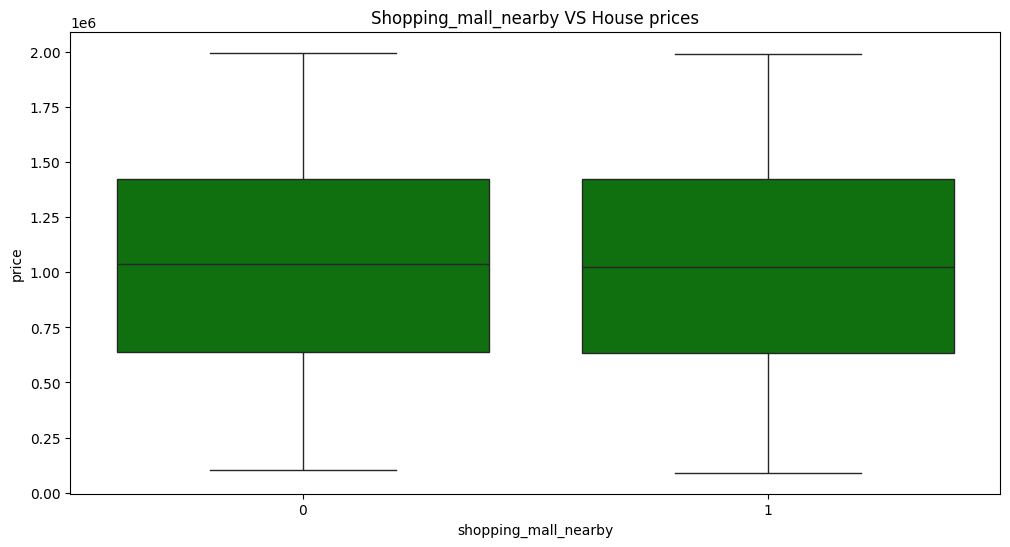

In [35]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x='shopping_mall_nearby', y="price", data=df, color='green')
plt.title("Shopping_mall_nearby VS House prices")
plt.show()

Compared to key features such as area and location, shopping mall proximity has a significantly weaker influence on house prices.

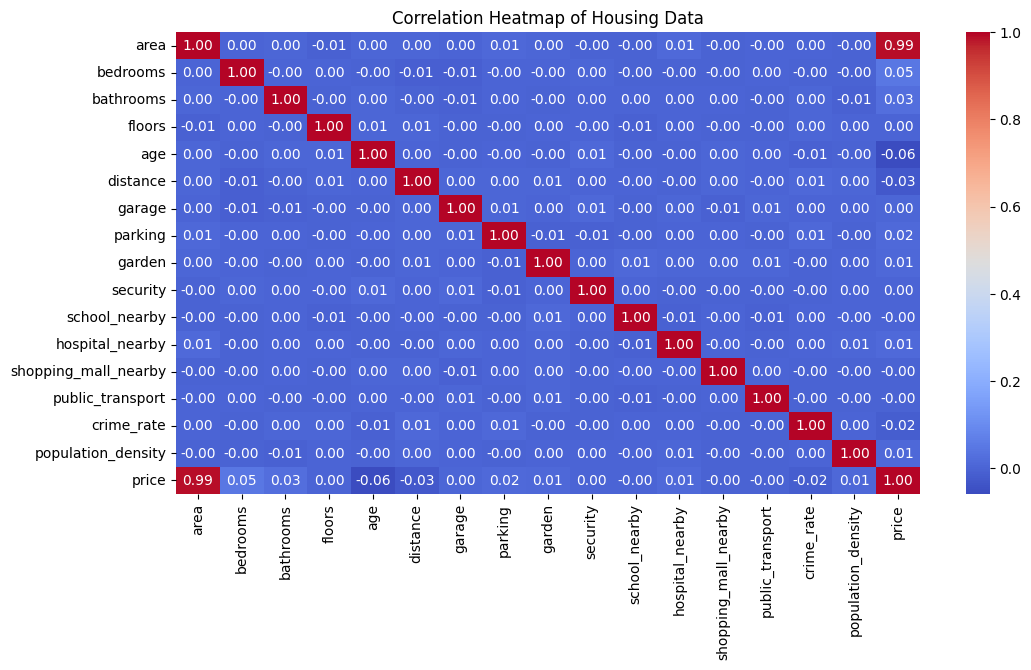

In [36]:
plt.figure(figsize=(12,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Housing Data")
plt.show()

# Conclusion
From the heatmap, I observed that area has a very strong positive correlation (0.99) with price, making it the most important feature. However, all other variables show near-zero correlation, indicating weak relationships. Hence, area is the primary predictor in this dataset.